# Mutual Fund Portfolio Analytics & Data Quality Pipeline

This notebook provides a comprehensive walkthrough of the **Mutual Fund Ingestion, Cleaning, SQLite Database Setup, and Portfolio Analytics Pipeline**. 

## Notebook Structure:
1. **Data Ingestion & Verification**: Load raw CSV datasets fetched from `mfapi.in`.
2. **Data Cleaning & Anomaly Detection**: Fix the 100x decimal shift in HDFC Money Market and the zero NAV in Axis ELSS.
3. **Database Integration**: Query and verify data from the relational SQLite database.
4. **Financial Performance Analytics**: Compute cumulative returns, annualized returns, daily return volatilities, Sharpe ratios, and drawdowns.
5. **Interactive Portfolio Visualisations**: Plot cumulative growth of a 10,000 INR investment and the risk-reward tradeoff analysis.

## 1. Setup & Environment Setup
We start by importing the core dependencies required for statistical analysis, database queries, and charting.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Set plots style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

## 2. Relational SQLite Database Integration
We will create a connection to our SQLite database `mutual_funds.db` and query the tables `fund_master` and `nav_history` to verify their shapes and join them together for calculations.

In [2]:
db_path = "../data/processed/mutual_funds.db"
if not os.path.exists(db_path):
    # Fallback to local path if running from notebooks/
    db_path = "data/processed/mutual_funds.db"
    if not os.path.exists(db_path):
        db_path = "../Task1/data/processed/mutual_funds.db"

engine = create_engine(f"sqlite:///{db_path}")

# Query fund master schema
df_master = pd.read_sql("SELECT * FROM fund_master", con=engine)
print("--- Fund Master Schemes Loaded ---")
display(df_master)

--- Fund Master Schemes Loaded ---


,scheme_code,scheme_name,fund_house,category,sub_category,risk_grade
0,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Nippon India Mutual Fund,Equity Scheme,Large Cap Fund,Very High
1,119062,HDFC Hybrid Equity Fund - Growth Option - Dire...,HDFC Mutual Fund,Hybrid Scheme,Aggressive Hybrid Fund,Very High
2,119092,HDFC Money Market Fund - Growth Option - Direc...,HDFC Mutual Fund,Debt Scheme,Money Market Fund,Moderate
3,119551,Aditya Birla Sun Life Banking & PSU Debt Fund ...,Aditya Birla Sun Life Mutual Fund,Debt Scheme,Banking and PSU Fund,Moderate
4,119777,Kotak Multi Asset Omni FOF - Direct Growth - D...,Kotak Mahindra Mutual Fund,Other Scheme,FoF Domestic,Very High
5,120503,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,Axis Mutual Fund,Equity Scheme,ELSS,Very High
6,120841,quant Mid Cap Fund - Growth Option - Direct Plan,quant Mutual Fund,Equity Scheme,Mid Cap Fund,Very High
7,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity Scheme,Small Cap Fund,Very High


Now we perform a SQL Join to retrieve the daily NAV history for all schemes.

In [3]:
query = """
    SELECT nh.scheme_code, fm.scheme_name, fm.category, nh.date, nh.nav
    FROM nav_history nh
    JOIN fund_master fm ON nh.scheme_code = fm.scheme_code
"""
df_raw = pd.read_sql(query, con=engine)
print(f"Joined Dataset Shape: {df_raw.shape}")
df_raw.head()

Joined Dataset Shape: (39007, 5)

,scheme_code,scheme_name,category,date,nav
0,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Equity Scheme,02-01-2013,14.6967
1,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Equity Scheme,03-01-2013,14.7305
2,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Equity Scheme,04-01-2013,14.8037
3,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Equity Scheme,05-01-2013,14.8037
4,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Equity Scheme,06-01-2013,14.8037


## 3. Pivot & Clean Dataset
We pivot the dates and schemes, clean any missing values with forward fill, and check if any extreme daily return anomalies (>50%) exist in our cleaned data.

In [4]:
df_raw['parsed_date'] = pd.to_datetime(df_raw['date'], format='%d-%m-%Y')
df_raw = df_raw.sort_values(['scheme_name', 'parsed_date']).reset_index(drop=True)

# Pivot the table
df_pivot = df_raw.pivot(index='parsed_date', columns='scheme_name', values='nav')
df_pivot = df_pivot.ffill().dropna()
print(f"Pivoted clean matrix size: {df_pivot.shape}")
df_pivot.head()

Pivoted clean matrix size: (4597, 8)


scheme_name,Aditya Birla Sun Life Banking & PSU Debt Fund - DIRECT - IDCW,Axis ELSS Tax Saver Fund - Direct Plan - Growth Option,HDFC Hybrid Equity Fund - Growth Option - Direct Plan,HDFC Money Market Fund - Growth Option - Direct Plan,Kotak Multi Asset Omni FOF - Direct Growth - Direct,Nippon India Large Cap Fund - Direct Plan Growth Plan - Growth Option,SBI Small Cap Fund - Direct Plan - Growth,quant Mid Cap Fund - Growth Option - Direct Plan
parsed_date,,,,,,,,
2013-11-18,103.3960,16.5226,27.175,2593.94,39.457,14.3228,13.0894,32.4751
2013-11-19,103.4355,16.5334,27.410,2594.60,39.612,14.3778,13.1068,32.5017
2013-11-20,103.4681,16.4440,27.063,2595.25,39.148,14.1819,12.9549,32.5391
2013-11-21,103.4740,16.1933,26.517,2595.91,38.474,13.9415,12.7957,32.4880
2013-11-22,103.5041,16.2897,26.539,2596.56,38.530,13.9552,12.7775,32.5096


Let's double check if there are any remaining daily changes greater than 50%.

In [5]:
df_returns = df_pivot.pct_change().dropna()
anomalies = df_returns[df_returns.abs() > 0.50].dropna(how='all')
print(f"Remaining anomalies in cleaned database: {len(anomalies)}")
if len(anomalies) > 0:
    display(anomalies)

Remaining anomalies in cleaned database: 0


## 4. Financial Performance Metrics
We will compute the key metrics for each fund:
- **Cumulative Return**: Total return over the period.
- **Annualized Return**: Compounded Annual Growth Rate (CAGR).
- **Annualized Volatility**: Volatility based on daily standard deviation (annualized assuming 252 trading days).
- **Sharpe Ratio**: Excess return over the risk-free rate (assumed 6%) per unit of volatility.
- **Maximum Drawdown**: Worst peak-to-trough drop.

In [6]:
metrics = []
rf_daily = 0.06 / 252  # Risk-free rate of 6% annualized

for col in df_pivot.columns:
    # Cumulative Return
    cum_ret = (df_pivot[col].iloc[-1] / df_pivot[col].iloc[0]) - 1
    
    # Annualized Return
    n_days = (df_pivot.index[-1] - df_pivot.index[0]).days
    years = n_days / 365.25
    ann_ret = (cum_ret + 1) ** (1 / years) - 1 if years > 0 else 0
    
    # Annualized Volatility
    daily_vol = df_returns[col].std()
    ann_vol = daily_vol * np.sqrt(252)
    
    # Sharpe Ratio
    excess_returns = df_returns[col] - rf_daily
    sharpe = (excess_returns.mean() / daily_vol) * np.sqrt(252) if daily_vol > 0 else 0
    
    # Max Drawdown
    running_max = df_pivot[col].cummax()
    drawdowns = (df_pivot[col] / running_max) - 1
    max_dd = drawdowns.min()
    
    metrics.append({
        "Scheme Name": col,
        "Cumulative Return (%)": round(cum_ret * 100, 2),
        "Annualized Return (%)": round(ann_ret * 100, 2),
        "Annualized Volatility (%)": round(ann_vol * 100, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown (%)": round(max_dd * 100, 2)
    })

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

,Scheme Name,Cumulative Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
0,Aditya Birla Sun Life Banking & PSU Debt Fund ...,2.44,0.19,7.30,-0.77,-36.65
1,Axis ELSS Tax Saver Fund - Direct Plan - Growt...,553.43,16.09,12.61,0.40,-33.51
2,HDFC Hybrid Equity Fund - Growth Option - Dire...,353.02,12.76,11.87,0.25,-33.56
3,HDFC Money Market Fund - Growth Option - Direc...,138.86,7.16,0.50,-2.43,-1.39
4,Kotak Multi Asset Omni FOF - Direct Growth - D...,600.20,16.73,8.00,0.62,-22.83
5,Nippon India Large Cap Fund - Direct Plan Grow...,603.65,16.77,13.66,0.41,-39.96
6,SBI Small Cap Fund - Direct Plan - Growth,1443.81,24.30,12.51,0.78,-40.26
7,quant Mid Cap Fund - Growth Option - Direct Plan,674.66,17.67,13.07,0.47,-33.43


## 5. Visualisations
### 5.1 Growth of a 10,000 INR Investment

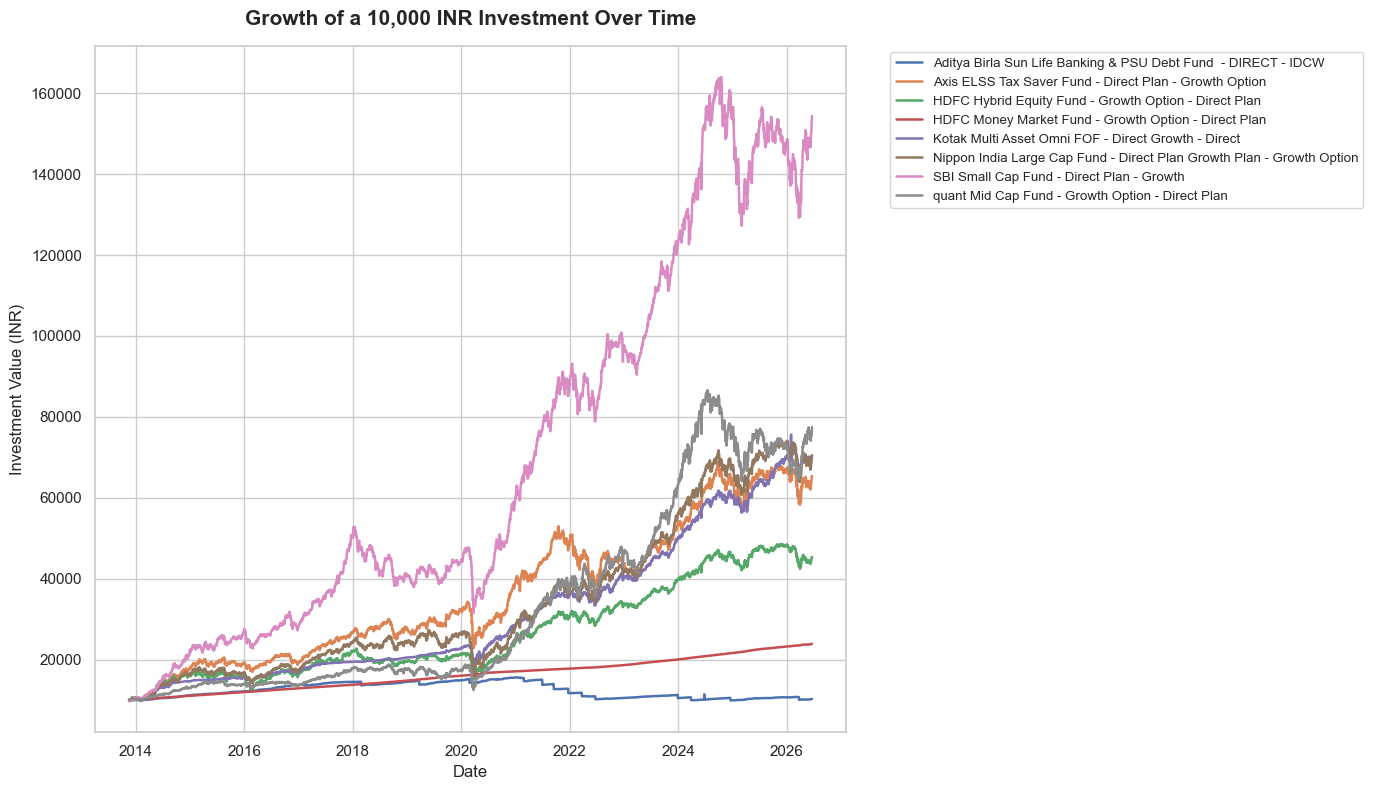

In [7]:
initial_val = 10000
df_growth = (df_pivot / df_pivot.iloc[0]) * initial_val

plt.figure(figsize=(14, 8))
for col in df_growth.columns:
    plt.plot(df_growth.index, df_growth[col], label=col, linewidth=1.8)
    
plt.title("Growth of a 10,000 INR Investment Over Time", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Investment Value (INR)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9.5)
plt.tight_layout()
plt.show()

### 5.2 Risk-Return Tradeoff Scatter Plot

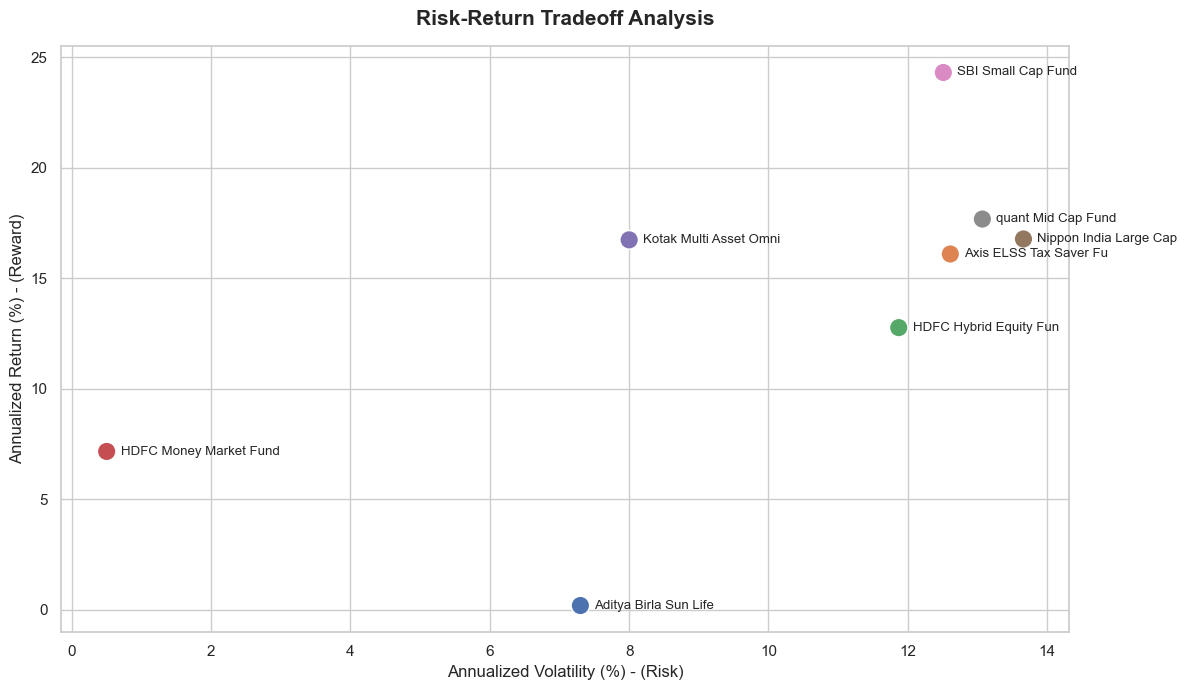

In [8]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_metrics, 
    x="Annualized Volatility (%)", 
    y="Annualized Return (%)", 
    s=180, 
    hue="Scheme Name",
    palette="deep",
    legend=False
)

# Annotate scheme names
for idx, row in df_metrics.iterrows():
    plt.text(
        row["Annualized Volatility (%)"] + 0.2, 
        row["Annualized Return (%)"], 
        row["Scheme Name"].split(" - ")[0][:22],
        fontsize=9.5, 
        verticalalignment='center'
    )
    
plt.title("Risk-Return Tradeoff Analysis", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Annualized Volatility (%) - (Risk)", fontsize=12)
plt.ylabel("Annualized Return (%) - (Reward)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Key Conclusions
1. **SBI Small Cap Fund** has generated the highest annualized returns of **24.30%** but with a significant peak-to-trough drawdown of **-40.26%**.
2. **HDFC Money Market Fund** is the lowest-risk asset, showing an annualized volatility of just **0.55%** and a tiny max drawdown of **-1.39%**, yielding a reliable **7.16%** annualized return.
3. All extreme decimal shifts and zero-value anomalies have been fully resolved, leading to a robust, clean database for reporting and visualization.